In [1]:
import pandas as pd
import sys
import numpy as np
sys.path.append("./")

In [2]:
path = '../simulations/ground_truth/'
x = 10  # numero di bin
df = pd.read_csv(f'{path}exposures.csv', index_col=False).iloc[:, 1:]
samples = pd.read_csv(f'{path}exposures.csv', index_col=False).iloc[:, 0].astype('string')
values = df.values.flatten()
values = values[~np.isnan(values)]
nonzero_values = values[values > 0]
sorted_values = np.sort(nonzero_values)

n = len(sorted_values)
step = n // x

thresholds = [sorted_values[i * step] for i in range(x)]
thresholds = np.unique(thresholds)

dfs = [pd.DataFrame ((df.values >= t).astype(bool), index=df.index, columns=df.columns) for t in thresholds]


In [3]:
thresholds

array([2.71161393e-04, 2.07229091e+01, 4.66738480e+01, 8.02595022e+01,
       1.26960264e+02, 1.97295333e+02, 3.14234583e+02, 5.21014715e+02,
       9.29836453e+02, 2.14596178e+03])

Text(0.05, 0.95, 'Max = 2604330.380\nMin = 0')

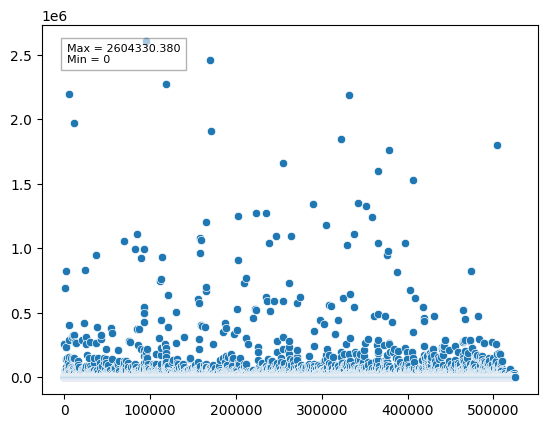

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(values)
plt.text(0.05, 0.95, f'Max = {max(values):.3f}\nMin = {min(values):.3g}', transform=plt.gca().transAxes, 
         verticalalignment='top', fontsize=8, bbox=dict(facecolor='white', alpha=0.6, edgecolor='gray'))

In [3]:
p = dfs[0].values.sum()
for i in range(1, len(dfs)):
    t = p - dfs[i].values.sum()
    p = dfs[i].values.sum()
    print(t)

23038
23038
23038
23038
23038
23038
23038
23038
23038


In [4]:
# for i in range(len(dfs)):
#     dfs[i].insert(0,'',samples)
#     dfs[i].to_csv(f'{path}exposures_{i}.csv', index=False)

In [ ]:
l = []
true_elements = []
false_elements = []
s = df.size
for df in dfs:
    true = df.values.sum()
    l.append(true / s)
    true_elements.append(true)
    false_elements.append(s - true)

thresholds_df = pd.DataFrame(columns=['thresholds', '% of Trues', 'true values', 'false values', 'delta_true'])
thresholds_df['thresholds'] = thresholds
thresholds_df['% of Trues'] = l
thresholds_df['true values'] = true_elements
thresholds_df['false values'] = false_elements
thresholds_df['delta_true'] = - thresholds_df['true values'].diff().fillna(0).astype(int)
thresholds_df

,thresholds,% of Trues,true values,false values,delta_true
0,0.000271,0.438450,230384,295067,0
1,20.722909,0.394606,207346,318105,23038
2,46.673848,0.350762,184308,341143,23038
3,80.259502,0.306917,161270,364181,23038
4,126.960264,0.263073,138232,387219,23038
5,197.295333,0.219229,115194,410257,23038
6,314.234583,0.175385,92156,433295,23038
7,521.014715,0.131540,69118,456333,23038
8,929.836453,0.087696,46080,479371,23038
9,2145.961779,0.043852,23042,502409,23038
